In [1]:
# ER Wait Time Analysis — Operations Analytics
# Author: Brittany McCleod
# Tool: Python (Pandas, Matplotlib, Seaborn)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset from GitHub
url = "https://raw.githubusercontent.com/bfreebnf12/ER-Wait-Time-Analysis/main/ER%20Wait%20Time%20Dataset.csv"
df = pd.read_csv(url)

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (5000, 19)

First 5 rows:


,Visit ID,Patient ID,Hospital ID,Hospital Name,Region,Visit Date,Day of Week,Season,Time of Day,Urgency Level,Nurse-to-Patient Ratio,Specialist Availability,Facility_Size_Beds,Time_to_Registration_min,Time_to_Triage_min,Time_to_Medical_Professional_min,Total_Wait_Time_min,Patient Outcome,Patient Satisfaction
0,HOSP-1-20240210-0001,PAT-00001,HOSP-1,Springfield General Hospital,Urban,2024-02-10 20:20:56,Saturday,Winter,Late Morning,Medium,4,3,92,17,22,66,105,Discharged,1
1,HOSP-3-20241128-0001,PAT-00002,HOSP-3,Northside Community Hospital,Rural,2024-11-28 02:07:47,Thursday,Fall,Evening,Medium,4,0,38,9,30,30,69,Discharged,3
2,HOSP-3-20240930-0002,PAT-00003,HOSP-3,Northside Community Hospital,Rural,2024-09-30 04:02:28,Monday,Fall,Evening,Low,5,1,38,38,40,125,203,Discharged,1
3,HOSP-2-20240227-0001,PAT-00004,HOSP-2,Riverside Medical Center,Urban,2024-02-27 00:31:13,Tuesday,Winter,Evening,High,4,5,94,8,16,64,88,Discharged,2
4,HOSP-1-20240306-0002,PAT-00005,HOSP-1,Springfield General Hospital,Urban,2024-03-06 16:52:26,Wednesday,Spring,Afternoon,Low,4,8,74,26,29,63,118,Discharged,1


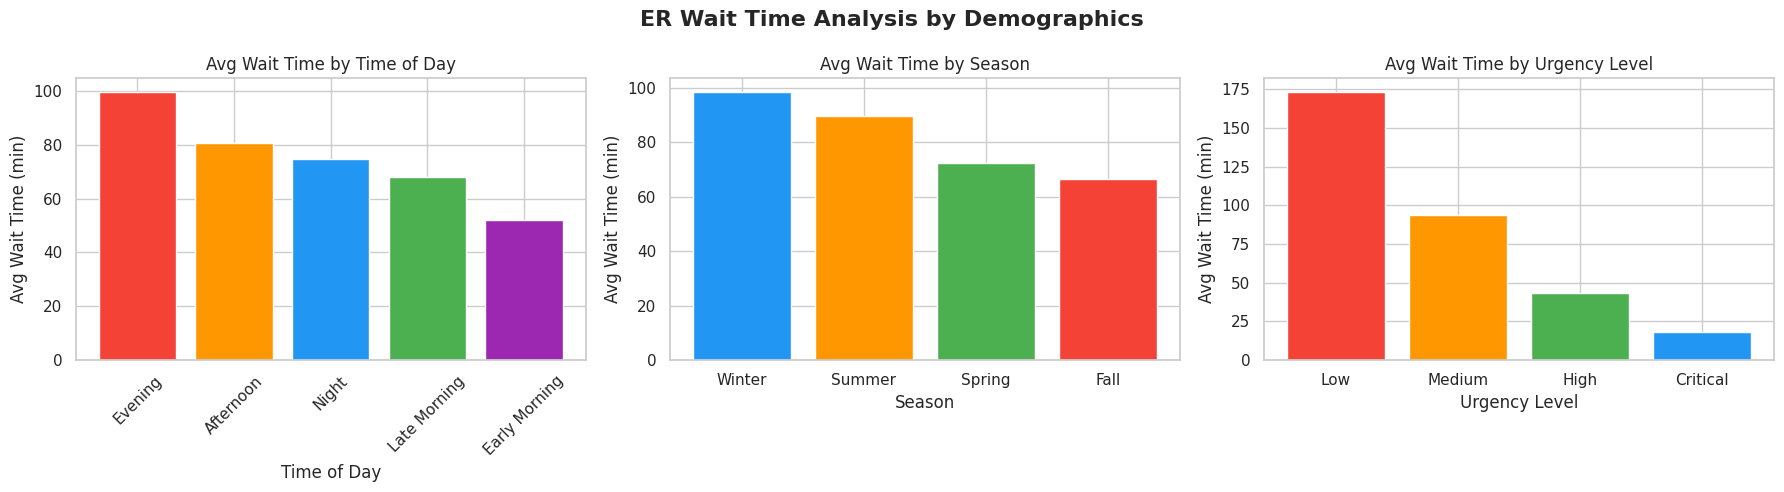

In [2]:
# Set visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ER Wait Time Analysis by Demographics', fontsize=16, fontweight='bold')

# Chart 1: Avg Wait Time by Time of Day
time_avg = df.groupby('Time of Day')['Total_Wait_Time_min'].mean().sort_values(ascending=False)
axes[0].bar(time_avg.index, time_avg.values, color=['#F44336','#FF9800','#2196F3','#4CAF50','#9C27B0'])
axes[0].set_title('Avg Wait Time by Time of Day')
axes[0].set_xlabel('Time of Day')
axes[0].set_ylabel('Avg Wait Time (min)')
axes[0].tick_params(axis='x', rotation=45)

# Chart 2: Avg Wait Time by Season
season_avg = df.groupby('Season')['Total_Wait_Time_min'].mean().sort_values(ascending=False)
axes[1].bar(season_avg.index, season_avg.values, color=['#2196F3','#FF9800','#4CAF50','#F44336'])
axes[1].set_title('Avg Wait Time by Season')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Avg Wait Time (min)')

# Chart 3: Avg Wait Time by Urgency Level
urgency_avg = df.groupby('Urgency Level')['Total_Wait_Time_min'].mean().sort_values(ascending=False)
axes[2].bar(urgency_avg.index, urgency_avg.values, color=['#F44336','#FF9800','#4CAF50','#2196F3'])
axes[2].set_title('Avg Wait Time by Urgency Level')
axes[2].set_xlabel('Urgency Level')
axes[2].set_ylabel('Avg Wait Time (min)')

plt.tight_layout()
plt.savefig('er_wait_time_analysis.png')
plt.show()